In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

from armored.models import *
from armored.preprocessing import *

import itertools
from tqdm import tqdm

import shap

params = {
    'figure.figsize': (3, 4),       # Figure size in inches
    'figure.dpi': 300,               # Resolution in dots per inch
    'axes.labelsize': 7,            # Font size of the axes labels
    'axes.titlesize': 7,            # Font size of the subplot titles
    'axes.titlepad': 10,             # Spacing between the subplot title and the plot
    'axes.linewidth': .5,           # Width of the axis lines
    'axes.grid': False,              # Display grid lines
    'axes.grid.axis': 'both',        # Display grid lines for both major and minor ticks
    'grid.alpha': 0.5,               # Transparency of the grid lines
    'grid.linewidth': 0.5,           # Width of the grid lines
    'xtick.labelsize': 7,           # Font size of the x-axis tick labels
    'ytick.labelsize': 7,           # Font size of the y-axis tick labels
    'xtick.major.size': 3,           # Length of the major x-axis ticks in points
    'xtick.major.width': .5,        # Width of the major x-axis ticks
    'ytick.major.size': 3,           # Length of the major y-axis ticks in points
    'ytick.major.width': .5,        # Width of the major y-axis ticks
    'xtick.minor.size': 2,           # Length of the minor x-axis ticks in points
    'xtick.minor.width': .5,        # Width of the minor x-axis ticks
    'ytick.minor.size': 2,           # Length of the minor y-axis ticks in points
    'ytick.minor.width': .5,        # Width of the minor y-axis ticks
    'xtick.direction': 'in',         # Direction of the x-axis ticks ('in', 'out', or 'inout')
    'ytick.direction': 'in',         # Direction of the y-axis ticks ('in', 'out', or 'inout')
    'legend.fontsize': 7,           # Font size of the legend
    'legend.frameon': True,          # Whether to draw a frame around the legend
    'legend.facecolor': 'inherit',   # Background color of the legend
    'legend.edgecolor': '0.8',       # Edge color of the legend
    'legend.framealpha': 0.8,        # Transparency of the legend frame
    'legend.loc': 'best',            # Location of the legend ('best', 'upper right', 'upper left', 'lower left', etc.)
    'legend.title_fontsize': 7,     # Font size of the legend title
    'svg.fonttype': 'none'           # Output font type for PDF files
}

plt.rcParams.update(params)

/home/jcthompson5@ad.wisc.edu/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# data with initial and end point measurements
df_exp0 = pd.read_csv("data/exp0/exp0_metabolites.csv")
df_exp1 = pd.read_csv("data/exp1/exp1_metabolites.csv")
df_exp2 = pd.read_csv("data/exp2/exp2_metabolites.csv")
df_exp3 = pd.read_csv("data/exp3/exp3_metabolites.csv")
df_exp4a = pd.read_csv("data/exp4/exp4_metabolites_best_reps.csv")
df_exp4b = pd.read_csv("data/exp4/exp4_metabolites_new_best.csv")
df_exp4c = pd.read_csv("data/exp4/exp4_metabolites_new_worst.csv")
df = pd.concat((df_exp0, df_exp1, df_exp2, df_exp3, df_exp4a, df_exp4b, df_exp4c))

# define variable names
species = ['ACabs', 'BAabs', 'BHabs', 'BLabs', 'BUabs', 'CAabs', 'CCabs', 'CHabs',
           'DFabs', 'ELabs', 'ERabs', 'FPabs', 'PCabs', 'PJabs', 'RIabs']
metabolites = ['pH', 'Lactate', 'Butyrate', 'Acetate']
controls = ['AcGum', 'ArGal', 'Inulin', 'Pectin', 'Starch', 'Xylan']

# concatenate all observed and all system variables 
observed = np.concatenate((np.array(species), np.array(metabolites)))
system_variables = np.concatenate((np.array(species), np.array(metabolites), np.array(controls)))
system_variables

# average replicates
df_fmt_mean = []
for exp_name, df_exp in df.groupby("Experiments"):
    df_groups = df_exp.groupby("Time")
    df_avg = df_groups[system_variables].mean().reset_index()
    df_avg.insert(0, "Experiments", [exp_name]*df_avg.shape[0])
    df_fmt_mean.append(df_avg)
df = pd.concat(df_fmt_mean)

In [14]:
len(np.unique(df.Experiments.values))

1185

In [16]:
100 * 1185 / 15138354 

0.007827799508453826

In [3]:
# log that ignores zeros
def zlog(x):
    x[x <= 0] = 1
    return np.log(x)

# shannon diversity
def shannon(y):
    y_rel = y / np.sum(y)
    return np.nansum(-zlog(y_rel)*y_rel)

# define objective 
def objective(y):
    # y is measured exp data [n_time, n_species + n_metabolites]
    
    # endpoint shannon diversity
    diversity = shannon(y[-1, :len(species)])
    
    # variance in species abundances in last two passages
    if np.any(np.isnan(y[-2:, :len(species)])):
        instability = np.nan
    else:
        species_stdv = np.std(y[-2:, :len(species)], 0)
        instability  = np.where(species_stdv>0, species_stdv, 0).mean() 
    
    # endpoint butyrate production 
    butyrate =  y[-1, -2]   
    
    return diversity, instability, butyrate

In [4]:
# determine names of experimental conditions 
all_treatments = df.Experiments.values
unique_treatments = np.unique(all_treatments) 

In [6]:
# scale data 
scaler = MinMaxScaler(observed, system_variables)
scaler.fit(df)
df_scaled = scaler.transform(df.copy())

# format data into matrix [n_samples, n_timepoints, dt+n_outputs+n_controls]
train_data = format_data(df, species, metabolites, controls, observed=observed)
train_data_scaled = format_data(df_scaled, species, metabolites, controls, observed=observed)

# instantiate model
brnn = miRNN(n_species=len(species), 
             n_metabolites=len(metabolites), 
             n_controls=len(controls), 
             n_hidden=32)

# fit model
brnn.fit(train_data_scaled, 
         alpha_0=0, alpha_1=1.,
         evd_tol=1e-3)

Total measurements: 27244, Number of parameters: 2515, Initial regularization: 0.00e+00
Loss: 1353.324, Residuals: -0.00492
Loss: 1268.678, Residuals: -0.00160
Loss: 1238.723, Residuals: 0.00099
Loss: 1209.082, Residuals: 0.00157
Loss: 1096.400, Residuals: 0.00427
Loss: 1069.116, Residuals: -0.00230
Loss: 1020.511, Residuals: -0.00057
Loss: 936.307, Residuals: -0.00050
Loss: 901.252, Residuals: -0.00078
Loss: 837.994, Residuals: 0.00022
Loss: 775.194, Residuals: -0.00014
Loss: 756.559, Residuals: -0.00078
Loss: 753.812, Residuals: -0.00079
Loss: 731.881, Residuals: -0.00079
Loss: 690.453, Residuals: -0.00138
Loss: 627.972, Residuals: -0.00147
Loss: 625.930, Residuals: -0.00145
Loss: 622.027, Residuals: -0.00123
Loss: 615.249, Residuals: -0.00089
Loss: 602.518, Residuals: -0.00093
Loss: 580.242, Residuals: -0.00105
Loss: 572.157, Residuals: -0.00192
Loss: 558.007, Residuals: -0.00153
Loss: 537.026, Residuals: -0.00146
Loss: 525.342, Residuals: -0.00136
Loss: 524.758, Residuals: -0.00132

In [95]:
# create wrapper for brnn to match SHAP model 
def butyrate_model(X):
    
    # X is matrix of [n_samples, n_inputs] 
    # Decompose X into Species/Metabolites and Fibers
    Xsm = X[:, :len(observed)]
    Xf = X[:, len(observed):]
    
    # matrix of predictions over time
    Xf = np.stack([np.stack(4*[Xfi]) for Xfi in Xf])
    Y = nn.relu(brnn.forward_batch(brnn.params, Xsm, Xf))
    
    # unscale endpoint
    Y_end = Y[:,-1,:]
    eval_time = 3
    Y_end *= (scaler.scale_dict_obs[f"{eval_time} max"] - scaler.scale_dict_obs[f"{eval_time} min"])
    Y_end += scaler.scale_dict_obs[f"{eval_time} min"]
    
    # return butyrate predictions
    return Y_end[:, -2]

In [96]:
# log that ignores zeros
def jax_zlog(x):
    return jnp.where(x > 0, jnp.log(x), 0.)

# shannon diversity
def jax_shannon(y):
    y_rel = y / jnp.sum(y)
    return jnp.nansum(-jax_zlog(y_rel)*y_rel)
batch_shannon = vmap(jax_shannon)

# create wrapper for brnn to match SHAP model 
def diversity_model(X):
    
    # X is matrix of [n_samples, n_inputs] 
    # Decompose X into Species/Metabolites and Fibers
    Xsm = X[:, :len(observed)]
    Xf = X[:, len(observed):]
    
    # matrix of predictions over time
    Xf = np.stack([np.stack(4*[Xfi]) for Xfi in Xf])
    Y = nn.relu(brnn.forward_batch(brnn.params, Xsm, Xf))
    
    # unscale endpoint
    Y_end = Y[:,-1,:]
    eval_time = 3
    Y_end *= (scaler.scale_dict_obs[f"{eval_time} max"] - scaler.scale_dict_obs[f"{eval_time} min"])
    Y_end += scaler.scale_dict_obs[f"{eval_time} min"]
    
    # return butyrate predictions
    return batch_shannon(Y_end[:,:len(species)])

In [97]:
# concatenate data points
Xs = []
all_exp_names = []

for (T, X, U, Y, exp_names) in train_data_scaled:
    
    all_exp_names.append(exp_names)
    for xi, ui in zip(X, U):
        
        # append design condition
        Xs.append(np.append(xi, ui[0]))
        
# stack 
X = np.stack(Xs)  
all_exp_names = np.concatenate(all_exp_names)

In [98]:
# synbiotic used in mouse
mouse_comm = 'AC-BA-BH-BL-BU-CH-DF-FP-RI-4Inulin-1Pectin-1Xylan'

# index of mouse comm
mouse_idx = np.in1d(all_exp_names, mouse_comm)

# mouse vector (has bu, not pc)
x_mouse = X[mouse_idx]

# mouse comm with PC and BU
pc_idx = list(species+controls).index('PCabs')
x_mouse_pc_bu = np.copy(x_mouse)
x_mouse_pc_bu[0, pc_idx] = 1.

# mouse comm with PC, without BU
bu_idx = list(species+controls).index('BUabs')
x_mouse_pc = np.copy(x_mouse_pc_bu)
x_mouse_pc[0, bu_idx] = 0.

# stack conditions
X_mouse = np.concatenate((x_mouse, x_mouse_pc, x_mouse_pc_bu))

In [99]:
# init SHAP explainer with baseline
baseline = np.zeros([1, X.shape[-1]])
# baseline is zero for species, metabolites and fibers but pH is always normalized to 1
baseline[0,list(system_variables).index('pH')] = 1.

# SHAP explainer
feature_names = np.array([v.split("abs")[0] for v in system_variables])
butyrate_explainer = shap.Explainer(butyrate_model, baseline, feature_names=feature_names, seed=1)
diversity_explainer = shap.Explainer(diversity_model, baseline, feature_names=feature_names, seed=1)

In [100]:
# explain conditions
butyrate_shap_values = butyrate_explainer(X_mouse)
diversity_shap_values = diversity_explainer(X_mouse)

In [145]:
# set colors of each species
ColorDict = {'AC':(0,0,1),
  'BA':(1.0000,0,0),
  'BH':(0,1.0000,0),
  'BL':(1.0000,0.1034,0.7241),
  'BU':(1.0000,0.8276,0),
  'CA':(0,0.3448,0),
  'CC':(0.5172,0.5172,1.0000),
  'CH':(0.6207,0.3103,0.2759),
  'DF':(0,1.0000,0.7586),
  'EL':(0,0.5172,0.5862),
  'ER':(0,0,0.4828),
  'FP':(0.5862,0.8276,0.3103),
  'PC':(0.9655,0.6207,0.8621),
  'PJ':(0.8276,0.0690,1.0000),
  'RI':(0.4828,0.1034,0.4138),
  'Inulin':'#C9A188',
  'Starch':'#E5E5B0',
  'Xylan':'#F3F3D8',
  'Pectin':'#D8C69D',
  'AcGum':'#904F4F',
  'ArGal':'#B96F6F'};

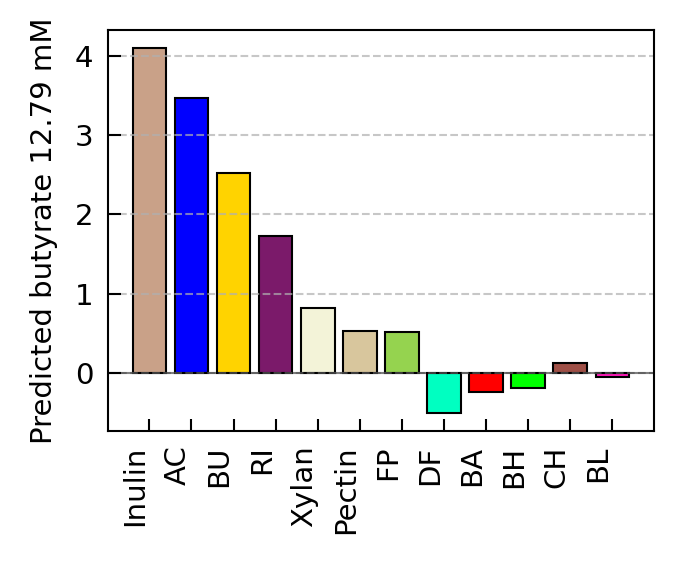

In [158]:
# Example SHAP values and feature names
feature_names = np.array([v.split("abs")[0] for v in system_variables])
shap_values = butyrate_shap_values[0].values  # SHAP values for each feature
n_shaps = sum(abs(shap_values)>0)

# 1. Sort features by absolute SHAP value (optional, for better visualization)
sorted_indices = np.argsort(np.abs(shap_values))[::-1]
shap_values = shap_values[sorted_indices][:n_shaps]
feature_names_plt = np.array(feature_names)[sorted_indices][:n_shaps]

# 2. Set up the plot
fig, ax = plt.subplots(figsize=(2.5, 2.1))  # Customize figure size

# 3. Create bar plot
colors = [ColorDict[ftr] for ftr in feature_names_plt]
bars = ax.bar(feature_names_plt, shap_values, color=colors, edgecolor='black', width=.8, linewidth=.5)

# add zero line
ax.axhline(y=0, c='k', alpha=.5, linewidth=.5)

# 5. Customize plot appearance
ax.set_ylabel("Predicted butyrate {:.2f} mM".format(np.sum(shap_values)))  # Y-axis label
# Add horizontal grid lines only
ax.grid(True, axis='y', linestyle='--', alpha=0.7, linewidth=.5)

# 6. Adjust layout and show the plot
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to avoid overlaps
plt.savefig("figures/motifs/mouse_BU_butyrate_SHAP.svg")
plt.show()

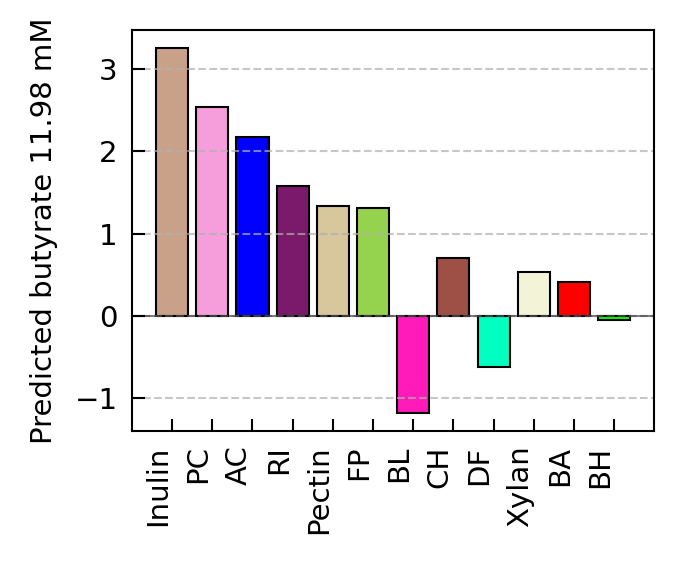

In [159]:
# Example SHAP values and feature names
feature_names = np.array([v.split("abs")[0] for v in system_variables])
shap_values = butyrate_shap_values[1].values  # SHAP values for each feature
n_shaps = sum(abs(shap_values)>0)

# 1. Sort features by absolute SHAP value (optional, for better visualization)
sorted_indices = np.argsort(np.abs(shap_values))[::-1]
shap_values = shap_values[sorted_indices][:n_shaps]
feature_names_plt = np.array(feature_names)[sorted_indices][:n_shaps]

# 2. Set up the plot
fig, ax = plt.subplots(figsize=(2.5, 2.1))  # Customize figure size

# 3. Create bar plot
colors = [ColorDict[ftr] for ftr in feature_names_plt]
bars = ax.bar(feature_names_plt, shap_values, color=colors, edgecolor='black', width=.8, linewidth=.5)

# add zero line
ax.axhline(y=0, c='k', alpha=.5, linewidth=.5)

# 5. Customize plot appearance
ax.set_ylabel("Predicted butyrate {:.2f} mM".format(np.sum(shap_values)))  # Y-axis label
# Add horizontal grid lines only
ax.grid(True, axis='y', linestyle='--', alpha=0.7, linewidth=.5)

# 6. Adjust layout and show the plot
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to avoid overlaps
plt.savefig("figures/motifs/mouse_PC_butyrate_SHAP.svg")
plt.show()

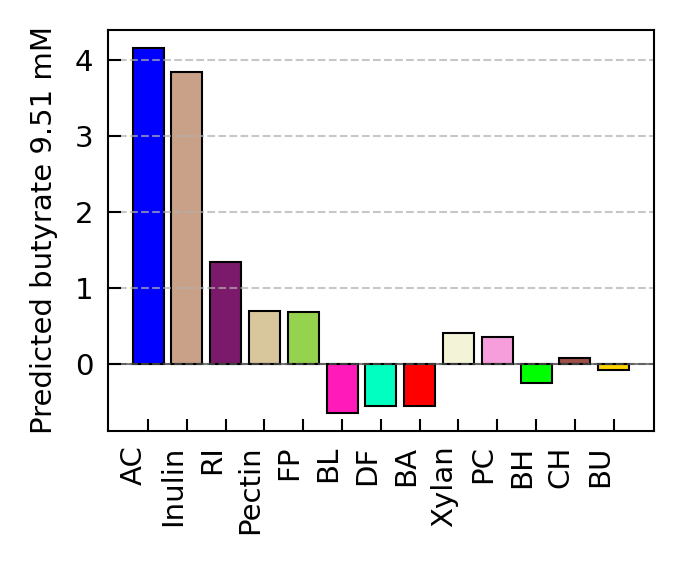

In [160]:
# Example SHAP values and feature names
feature_names = np.array([v.split("abs")[0] for v in system_variables])
shap_values = butyrate_shap_values[2].values  # SHAP values for each feature
n_shaps = sum(abs(shap_values)>0)

# 1. Sort features by absolute SHAP value (optional, for better visualization)
sorted_indices = np.argsort(np.abs(shap_values))[::-1]
shap_values = shap_values[sorted_indices][:n_shaps]
feature_names_plt = np.array(feature_names)[sorted_indices][:n_shaps]

# 2. Set up the plot
fig, ax = plt.subplots(figsize=(2.5, 2.1))  # Customize figure size

# 3. Create bar plot
colors = [ColorDict[ftr] for ftr in feature_names_plt]
bars = ax.bar(feature_names_plt, shap_values, color=colors, edgecolor='black', width=.8, linewidth=.5)

# add zero line
ax.axhline(y=0, c='k', alpha=.5, linewidth=.5)

# 5. Customize plot appearance
ax.set_ylabel("Predicted butyrate {:.2f} mM".format(np.sum(shap_values)))  # Y-axis label
# Add horizontal grid lines only
ax.grid(True, axis='y', linestyle='--', alpha=0.7, linewidth=.5)

# 6. Adjust layout and show the plot
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels if needed
plt.tight_layout()  # Adjust layout to avoid overlaps
plt.savefig("figures/motifs/mouse_BU_PC_butyrate_SHAP.svg")
plt.show()

In [5]:
# are BU and PC negatively correlated?

# samples that have both bu and pc
dfs_bu_pc = []

# samples that have bu and not pc
dfs_bu = []

# samples that have pc and not bu
dfs_pc = []

for exp_name, df_exp in df.groupby("Experiments"):
    
    if 'BU' in exp_name and 'PC' in exp_name:
        dfs_bu_pc.append(df_exp)
        
    if 'BU' in exp_name and 'PC' not in exp_name:
        dfs_bu.append(df_exp)
        
    if 'BU' not in exp_name and 'PC' in exp_name:
        dfs_pc.append(df_exp)
        
dfs_bu_pc = pd.concat(dfs_bu_pc)
dfs_bu = pd.concat(dfs_bu)
dfs_pc = pd.concat(dfs_pc)

In [6]:
bu_abs = dfs_bu_pc.iloc[dfs_bu_pc.Time.values>0]['BUabs'].values
pc_abs = dfs_bu_pc.iloc[dfs_bu_pc.Time.values>0]['PCabs'].values

In [7]:
from scipy.stats import spearmanr, pearsonr

In [8]:
inds_nan = np.isnan(bu_abs + pc_abs)
rho, pval = pearsonr(bu_abs[~inds_nan], pc_abs[~inds_nan])

In [9]:
rho

-0.0049818118838247105

In [10]:
pval

0.9014763568082749

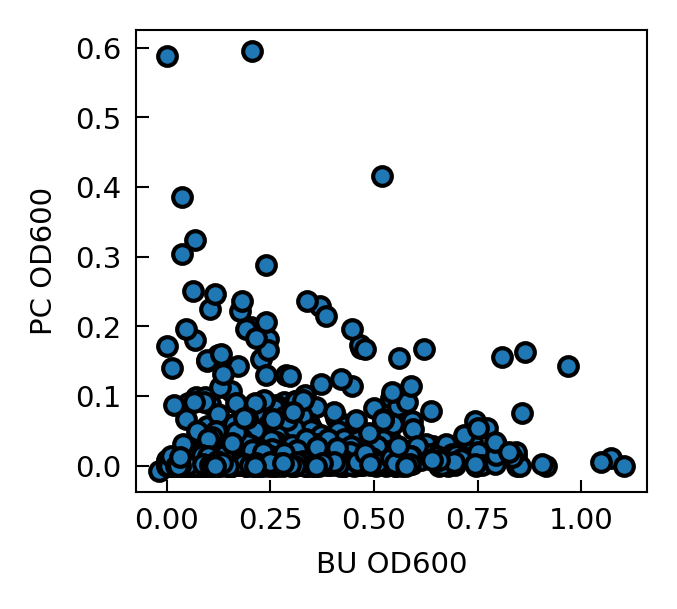

In [12]:
plt.figure(figsize=(2.2, 2))
plt.scatter(bu_abs[~inds_nan], pc_abs[~inds_nan], s=20, edgecolor='k')
plt.xlabel("BU OD600")
plt.ylabel("PC OD600")
plt.savefig("figures/motifs/PC_vs_BU.svg", dpi=300)
plt.show()

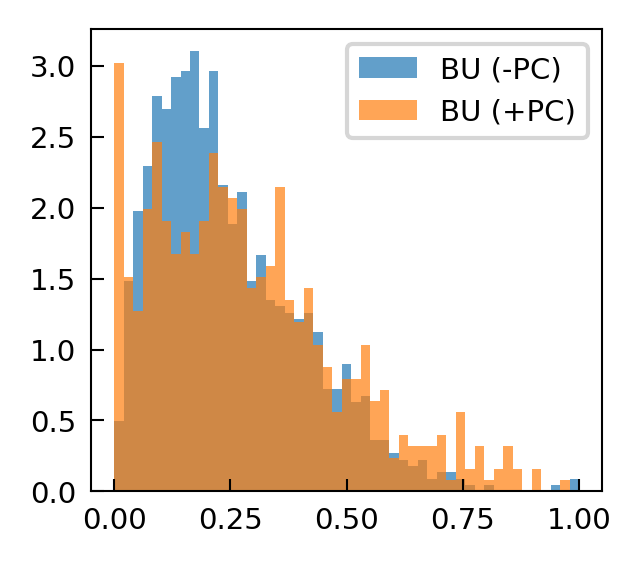

In [23]:
# bu abundance without pc 
bu_alone = dfs_bu.iloc[dfs_bu.Time.values>0]['BUabs'].values

plt.figure(figsize=(2.2, 2))
bins = np.linspace(0, 1)
plt.hist(bu_alone, bins=bins, label='BU (-PC)', density=True, alpha=.7)
plt.hist(bu_abs, bins=bins, label='BU (+PC)', density=True, alpha=.7)
plt.legend()
plt.show()

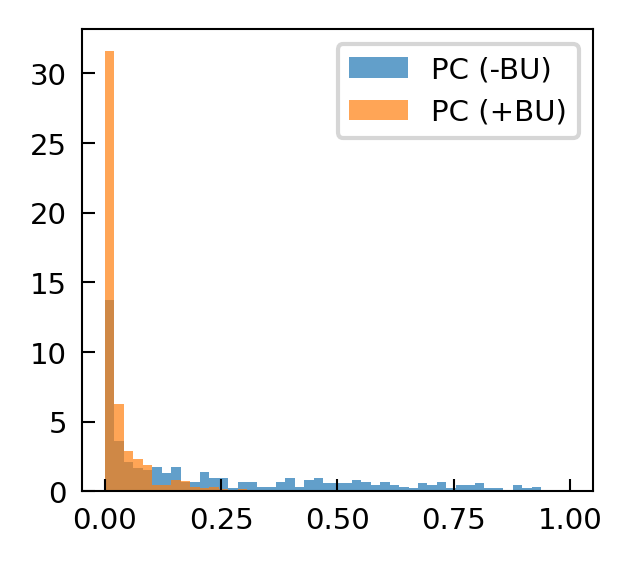

In [24]:
# pc abundance without bu
pc_alone = dfs_pc.iloc[dfs_pc.Time.values>0]['PCabs'].values

plt.figure(figsize=(2.2, 2))
bins = np.linspace(0, 1)
plt.hist(pc_alone, bins=bins, label='PC (-BU)', density=True, alpha=.7)
plt.hist(pc_abs, bins=bins, label='PC (+BU)', density=True, alpha=.7)
plt.legend()
plt.show()